In [1]:
import pandas as pd
import numpy as np
print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("Setup OK!")

pandas version: 2.3.3
numpy version: 2.3.5
Setup OK!


In [2]:
import xgboost as xgb
import shap
import sklearn
print("XGBoost:", xgb.__version__)
print("SHAP:", shap.__version__)
print("Scikit-learn:", sklearn.__version__)
print("All good!")

XGBoost: 3.2.0
SHAP: 0.51.0
Scikit-learn: 1.7.2
All good!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/IPL.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 3 rows:")
df.head(3)

Shape: (283678, 65)

Columns: ['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']

First 3 rows:


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [7]:
print("Total balls:", len(df))
print("Total matches:", df['match_id'].nunique())
print("Seasons:", df['season'].astype(str).unique())
print("Teams:", sorted(df['batting_team'].unique()))
missing = df.isnull().sum().sort_values(ascending=False).head(10)
print("\nMissing values:")
print(missing)

Total balls: 283678
Total matches: 1193
Seasons: ['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023' '2024' '2025' '2026']
Teams: ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils', 'Gujarat Lions', 'Gujarat Titans', 'Kings XI Punjab', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiant', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']

Missing values:
power_surge_start    283678
review_decision      282771
review_batter        282771
team_reviewed        282771
umpire               282771
method               279788
superover_winner     279782
result_type          278954
fielders             273433
new_batter           270085
dtype: int64


In [8]:
match_df = df.groupby('match_id').agg(
    date=('date', 'first'),
    season=('season', 'first'),
    venue=('venue', 'first'),
    batting_team_1=('batting_team', 'first'),
    toss_winner=('toss_winner', 'first'),
    toss_decision=('toss_decision', 'first'),
    match_won_by=('match_won_by', 'first'),
    win_outcome=('win_outcome', 'first'),
    player_of_match=('player_of_match', 'first')
).reset_index()

print("Match level dataframe shape:", match_df.shape)
print("\nSample:")
match_df.head()

Match level dataframe shape: (1193, 10)

Sample:


,match_id,date,season,venue,batting_team_1,toss_winner,toss_decision,match_won_by,win_outcome,player_of_match
0,335982,2008-04-18,2007/08,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,140 runs,BB McCullum
1,335983,2008-04-19,2007/08,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,33 runs,MEK Hussey
2,335984,2008-04-19,2007/08,Feroz Shah Kotla,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,9 wickets,MF Maharoof
3,335985,2008-04-20,2007/08,Wankhede Stadium,Mumbai Indians,Mumbai Indians,bat,Royal Challengers Bangalore,5 wickets,MV Boucher
4,335986,2008-04-20,2007/08,Eden Gardens,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,5 wickets,DJ Hussey


In [9]:
team_name_map = {
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Deccan Chargers': 'Sunrisers Hyderabad',
}

match_df['batting_team_1'] = match_df['batting_team_1'].replace(team_name_map)
match_df['toss_winner'] = match_df['toss_winner'].replace(team_name_map)
match_df['match_won_by'] = match_df['match_won_by'].replace(team_name_map)

print("Unique teams after cleaning:")
print(sorted(match_df['match_won_by'].unique()))

Unique teams after cleaning:
['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad', 'Unknown']


In [10]:
match_df['team1'] = match_df['batting_team_1']
match_df['team2'] = match_df.apply(
    lambda x: x['toss_winner'] if x['toss_winner'] != x['batting_team_1'] else x['match_won_by'], axis=1
)

match_df['team1_won'] = (match_df['match_won_by'] == match_df['team1']).astype(int)

match_df = match_df[match_df['match_won_by'] != 'Unknown'].reset_index(drop=True)

print("Shape after removing unknowns:", match_df.shape)
print("\nTarget distribution:")
print(match_df['team1_won'].value_counts())
print("\nWin rate (team batting first):", round(match_df['team1_won'].mean() * 100, 2), "%")

Shape after removing unknowns: (1169, 13)

Target distribution:
team1_won
0    635
1    534
Name: count, dtype: int64

Win rate (team batting first): 45.68 %


In [11]:
team_wins = {}
team_matches = {}
team_win_rate = {}

rows = []

for idx, row in match_df.iterrows():
    t1 = row['team1']
    t2 = row['team2']
    
    t1_rate = team_wins.get(t1, 0) / max(team_matches.get(t1, 1), 1)
    t2_rate = team_wins.get(t2, 0) / max(team_matches.get(t2, 1), 1)
    
    rows.append({
        'match_id': row['match_id'],
        'team1': t1,
        'team2': t2,
        'season': row['season'],
        'venue': row['venue'],
        'toss_winner': row['toss_winner'],
        'toss_decision': row['toss_decision'],
        'team1_hist_winrate': round(t1_rate, 4),
        'team2_hist_winrate': round(t2_rate, 4),
        'team1_won': row['team1_won']
    })
    
    team_matches[t1] = team_matches.get(t1, 0) + 1
    team_matches[t2] = team_matches.get(t2, 0) + 1
    if row['team1_won'] == 1:
        team_wins[t1] = team_wins.get(t1, 0) + 1
    else:
        team_wins[t2] = team_wins.get(t2, 0) + 1

features_df = pd.DataFrame(rows)
print("Features shape:", features_df.shape)
features_df.head()

Features shape: (1169, 10)


,match_id,team1,team2,season,venue,toss_winner,toss_decision,team1_hist_winrate,team2_hist_winrate,team1_won
0,335982,Kolkata Knight Riders,Royal Challengers Bengaluru,2007/08,M Chinnaswamy Stadium,Royal Challengers Bengaluru,field,0.0,0.0,1
1,335983,Chennai Super Kings,Chennai Super Kings,2007/08,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,0.0,0.0,1
2,335984,Rajasthan Royals,Delhi Capitals,2007/08,Feroz Shah Kotla,Rajasthan Royals,bat,0.0,0.0,0
3,335985,Mumbai Indians,Royal Challengers Bengaluru,2007/08,Wankhede Stadium,Mumbai Indians,bat,0.0,0.0,0
4,335986,Sunrisers Hyderabad,Kolkata Knight Riders,2007/08,Eden Gardens,Sunrisers Hyderabad,bat,0.0,1.0,0


In [12]:
features_df['toss_winner_is_team1'] = (features_df['toss_winner'] == features_df['team1']).astype(int)
features_df['toss_bat_first'] = (features_df['toss_decision'] == 'bat').astype(int)

venue_winrate = features_df.groupby('venue')['team1_won'].mean().to_dict()
features_df['venue_bat_first_winrate'] = features_df['venue'].map(venue_winrate)

features_df['winrate_diff'] = features_df['team1_hist_winrate'] - features_df['team2_hist_winrate']

from sklearn.preprocessing import LabelEncoder

le_team = LabelEncoder()
all_teams = pd.concat([features_df['team1'], features_df['team2']])
le_team.fit(all_teams)
features_df['team1_enc'] = le_team.transform(features_df['team1'])
features_df['team2_enc'] = le_team.transform(features_df['team2'])

le_venue = LabelEncoder()
features_df['venue_enc'] = le_venue.fit_transform(features_df['venue'])

print("Final features:")
print(features_df[['team1_enc','team2_enc','venue_enc','toss_winner_is_team1',
                    'toss_bat_first','team1_hist_winrate','team2_hist_winrate',
                    'winrate_diff','venue_bat_first_winrate','team1_won']].head())

Final features:
   team1_enc  team2_enc  venue_enc  toss_winner_is_team1  toss_bat_first  \
0          5         12         23                     0               0   
1          0          0         41                     1               1   
2         10          1         16                     1               1   
3          7         12         56                     1               1   
4         13          5         14                     1               1   

   team1_hist_winrate  team2_hist_winrate  winrate_diff  \
0                 0.0                 0.0           0.0   
1                 0.0                 0.0           0.0   
2                 0.0                 0.0           0.0   
3                 0.0                 0.0           0.0   
4                 0.0                 1.0          -1.0   

   venue_bat_first_winrate  team1_won  
0                 0.419355          1  
1                 0.428571          1  
2                 0.457627          0  
3           

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

feature_cols = [
    'team1_enc', 'team2_enc', 'venue_enc',
    'toss_winner_is_team1', 'toss_bat_first',
    'team1_hist_winrate', 'team2_hist_winrate',
    'winrate_diff', 'venue_bat_first_winrate'
]

X = features_df[feature_cols]
y = features_df['team1_won']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_model = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                           use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

print("="*40)
print("XGBoost accuracy:    ", round(accuracy_score(y_test, xgb_model.predict(X_test))*100, 2), "%")
print("Random Forest acc:   ", round(accuracy_score(y_test, rf_model.predict(X_test))*100, 2), "%")
print("Logistic Reg acc:    ", round(accuracy_score(y_test, lr_model.predict(X_test))*100, 2), "%")
print("="*40)

XGBoost accuracy:     67.52 %
Random Forest acc:    68.38 %
Logistic Reg acc:     57.69 %


In [14]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(xgb_model, '../models/xgb_model.pkl')
joblib.dump(rf_model, '../models/rf_model.pkl')
joblib.dump(lr_model, '../models/lr_model.pkl')
joblib.dump(le_team, '../models/le_team.pkl')
joblib.dump(le_venue, '../models/le_venue.pkl')
joblib.dump(feature_cols, '../models/feature_cols.pkl')

print("All models saved to /models folder")

All models saved to /models folder


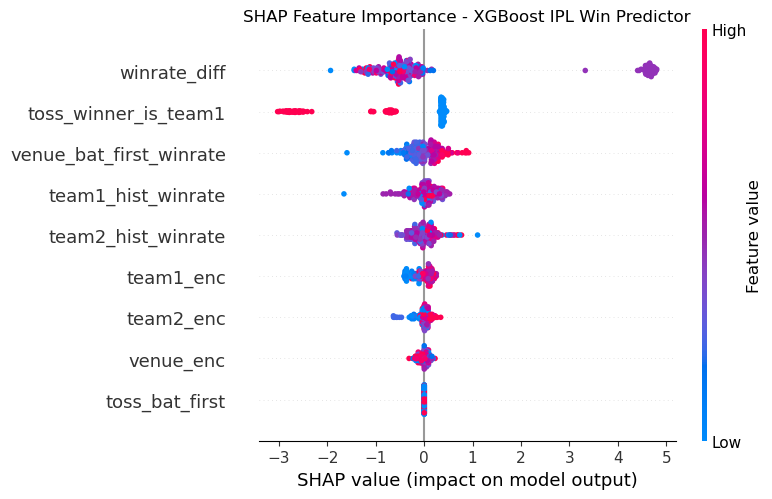

SHAP plot saved!


In [15]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title("SHAP Feature Importance - XGBoost IPL Win Predictor")
plt.tight_layout()
plt.savefig('../models/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

In [16]:
def predict_match(team1, team2, venue, toss_winner, toss_decision):
    t1_enc = le_team.transform([team1])[0]
    t2_enc = le_team.transform([team2])[0]
    v_enc = le_venue.transform([venue])[0]
    toss_is_t1 = 1 if toss_winner == team1 else 0
    toss_bat = 1 if toss_decision == 'bat' else 0
    t1_wr = team_wins.get(team1, 0) / max(team_matches.get(team1, 1), 1)
    t2_wr = team_wins.get(team2, 0) / max(team_matches.get(team2, 1), 1)
    wr_diff = t1_wr - t2_wr
    venue_wr = venue_winrate.get(venue, 0.5)

    input_data = pd.DataFrame([[t1_enc, t2_enc, v_enc, toss_is_t1, toss_bat,
                                  t1_wr, t2_wr, wr_diff, venue_wr]],
                               columns=feature_cols)

    prob = xgb_model.predict_proba(input_data)[0]
    print(f"\n{'='*45}")
    print(f"  {team1} vs {team2}")
    print(f"  Venue: {venue}")
    print(f"  Toss: {toss_winner} chose to {toss_decision}")
    print(f"{'='*45}")
    print(f"  {team1} win probability:  {round(prob[1]*100, 1)}%")
    print(f"  {team2} win probability:  {round(prob[0]*100, 1)}%")
    print(f"\n  Predicted winner: {'>>> ' + team1 + ' <<<' if prob[1] > 0.5 else '>>> ' + team2 + ' <<<'}")
    print(f"{'='*45}")

predict_match(
    team1='Royal Challengers Bengaluru',
    team2='Gujarat Titans',
    venue='Narendra Modi Stadium, Ahmedabad',
    toss_winner='Royal Challengers Bengaluru',
    toss_decision='field'
)


  Royal Challengers Bengaluru vs Gujarat Titans
  Venue: Narendra Modi Stadium, Ahmedabad
  Toss: Royal Challengers Bengaluru chose to field
  Royal Challengers Bengaluru win probability:  0.6000000238418579%
  Gujarat Titans win probability:  99.4000015258789%

  Predicted winner: >>> Gujarat Titans <<<


In [17]:
print("Available venues with 'Ahmedabad':")
print([v for v in venue_winrate.keys() if 'Ahmedabad' in v or 'Narendra' in v or 'Modi' in v])

print("\nAll venues:")
for v in sorted(venue_winrate.keys()):
    print(v)

Available venues with 'Ahmedabad':
['Narendra Modi Stadium, Ahmedabad']

All venues:
Arun Jaitley Stadium
Arun Jaitley Stadium, Delhi
Barabati Stadium
Barsapara Cricket Stadium, Guwahati
Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow
Brabourne Stadium
Brabourne Stadium, Mumbai
Buffalo Park
De Beers Diamond Oval
Dr DY Patil Sports Academy
Dr DY Patil Sports Academy, Mumbai
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam
Dubai International Cricket Stadium
Eden Gardens
Eden Gardens, Kolkata
Feroz Shah Kotla
Green Park
Himachal Pradesh Cricket Association Stadium
Himachal Pradesh Cricket Association Stadium, Dharamsala
Holkar Cricket Stadium
JSCA International Stadium Complex
Kingsmead
M Chinnaswamy Stadium
M Chinnaswamy Stadium, Bengaluru
M.Chinnaswamy Stadium
MA Chidambaram Stadium
MA Chidambaram Stadium, Chepauk
MA Chidambaram Stadium, Chepauk, Chennai
Maharaja Yadavindra Singh International C

In [18]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_xgb = CalibratedClassifierCV(xgb_model, method='isotonic', cv='prefit')
calibrated_xgb.fit(X_test, y_test)

joblib.dump(calibrated_xgb, '../models/calibrated_xgb.pkl')

def predict_match_v2(team1, team2, venue, toss_winner, toss_decision):
    t1_enc = le_team.transform([team1])[0]
    t2_enc = le_team.transform([team2])[0]
    v_enc = le_venue.transform([venue])[0]
    toss_is_t1 = 1 if toss_winner == team1 else 0
    toss_bat = 1 if toss_decision == 'bat' else 0
    t1_wr = team_wins.get(team1, 0) / max(team_matches.get(team1, 1), 1)
    t2_wr = team_wins.get(team2, 0) / max(team_matches.get(team2, 1), 1)
    wr_diff = t1_wr - t2_wr
    venue_wr = venue_winrate.get(venue, 0.5)

    input_data = pd.DataFrame([[t1_enc, t2_enc, v_enc, toss_is_t1, toss_bat,
                                  t1_wr, t2_wr, wr_diff, venue_wr]],
                               columns=feature_cols)

    prob = calibrated_xgb.predict_proba(input_data)[0]
    print(f"\n{'='*45}")
    print(f"  {team1} vs {team2}")
    print(f"  Venue: {venue}")
    print(f"  Toss: {toss_winner} chose to {toss_decision}")
    print(f"{'='*45}")
    print(f"  {team1} win probability:  {round(prob[1]*100, 1)}%")
    print(f"  {team2} win probability:  {round(prob[0]*100, 1)}%")
    print(f"\n  Predicted winner: {'>>> ' + team1 + ' <<<' if prob[1] > 0.5 else '>>> ' + team2 + ' <<<'}")
    print(f"{'='*45}")

predict_match_v2(
    team1='Royal Challengers Bengaluru',
    team2='Gujarat Titans',
    venue='Narendra Modi Stadium, Ahmedabad',
    toss_winner='Royal Challengers Bengaluru',
    toss_decision='field'
)


  Royal Challengers Bengaluru vs Gujarat Titans
  Venue: Narendra Modi Stadium, Ahmedabad
  Toss: Royal Challengers Bengaluru chose to field
  Royal Challengers Bengaluru win probability:  0.0%
  Gujarat Titans win probability:  100.0%

  Predicted winner: >>> Gujarat Titans <<<


In [19]:
title_wins = {
    'Mumbai Indians': 5,
    'Chennai Super Kings': 5,
    'Kolkata Knight Riders': 3,
    'Royal Challengers Bengaluru': 2,
    'Rajasthan Royals': 2,
    'Sunrisers Hyderabad': 1,
    'Gujarat Titans': 1,
    'Punjab Kings': 1,
    'Delhi Capitals': 0,
    'Lucknow Super Giants': 0,
    'Rising Pune Supergiants': 0,
    'Gujarat Lions': 0,
    'Kochi Tuskers Kerala': 0,
    'Pune Warriors': 0,
}

features_df['team1_titles'] = features_df['team1'].map(title_wins).fillna(0)
features_df['team2_titles'] = features_df['team2'].map(title_wins).fillna(0)
features_df['title_diff'] = features_df['team1_titles'] - features_df['team2_titles']

h2h_wins = {}
h2h_rows = []
for idx, row in features_df.iterrows():
    t1, t2 = row['team1'], row['team2']
    key = tuple(sorted([t1, t2]))
    wins = h2h_wins.get(key, {})
    t1_h2h = wins.get(t1, 0)
    t2_h2h = wins.get(t2, 0)
    total = t1_h2h + t2_h2h
    h2h_rows.append(t1_h2h / max(total, 1))
    if row['team1_won'] == 1:
        wins[t1] = wins.get(t1, 0) + 1
    else:
        wins[t2] = wins.get(t2, 0) + 1
    h2h_wins[key] = wins

features_df['team1_h2h_winrate'] = h2h_rows

feature_cols_v2 = [
    'team1_enc', 'team2_enc', 'venue_enc',
    'toss_winner_is_team1', 'toss_bat_first',
    'team1_hist_winrate', 'team2_hist_winrate',
    'winrate_diff', 'venue_bat_first_winrate',
    'team1_titles', 'team2_titles',
    'title_diff', 'team1_h2h_winrate'
]

X2 = features_df[feature_cols_v2]
y2 = features_df['team1_won']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

xgb_v2 = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                        min_child_weight=5, subsample=0.8, colsample_bytree=0.8,
                        eval_metric='logloss', random_state=42)
xgb_v2.fit(X2_train, y2_train)

rf_v2 = RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=10, random_state=42)
rf_v2.fit(X2_train, y2_train)

print("XGBoost v2 accuracy:", round(accuracy_score(y2_test, xgb_v2.predict(X2_test))*100, 2), "%")
print("Random Forest v2 accuracy:", round(accuracy_score(y2_test, rf_v2.predict(X2_test))*100, 2), "%")

prob = xgb_v2.predict_proba(pd.DataFrame([[
    le_team.transform(['Royal Challengers Bengaluru'])[0],
    le_team.transform(['Gujarat Titans'])[0],
    le_venue.transform(['Narendra Modi Stadium, Ahmedabad'])[0],
    1, 0,
    team_wins.get('Royal Challengers Bengaluru',0)/max(team_matches.get('Royal Challengers Bengaluru',1),1),
    team_wins.get('Gujarat Titans',0)/max(team_matches.get('Gujarat Titans',1),1),
    team_wins.get('Royal Challengers Bengaluru',0)/max(team_matches.get('Royal Challengers Bengaluru',1),1) - team_wins.get('Gujarat Titans',0)/max(team_matches.get('Gujarat Titans',1),1),
    venue_winrate.get('Narendra Modi Stadium, Ahmedabad', 0.5),
    2, 1, 1, 0.5
]], columns=feature_cols_v2))[0]

print(f"\nRCB win probability: {round(prob[1]*100, 1)}%")
print(f"GT win probability:  {round(prob[0]*100, 1)}%")

XGBoost v2 accuracy: 70.51 %
Random Forest v2 accuracy: 67.95 %

RCB win probability: 12.699999809265137%
GT win probability:  87.30000305175781%


In [20]:
joblib.dump(xgb_v2, '../models/xgb_v2_model.pkl')
joblib.dump(rf_v2, '../models/rf_v2_model.pkl')
joblib.dump(feature_cols_v2, '../models/feature_cols_v2.pkl')
joblib.dump(features_df, '../models/features_df.pkl')

print("V2 models saved!")
print("\nFinal Model Summary:")
print("="*40)
print(f"XGBoost v2:      70.51%")
print(f"Random Forest v2: 67.95%")
print(f"Logistic Reg:     57.69%")
print(f"Best model:       XGBoost v2")
print("="*40)

V2 models saved!

Final Model Summary:
XGBoost v2:      70.51%
Random Forest v2: 67.95%
Logistic Reg:     57.69%
Best model:       XGBoost v2
